# Exploratory Data Analysis - NinaPro

In [5]:
# Recarrega automaticamente as mudanças nos arquivos .py
%load_ext autoreload
%autoreload 2

import sys
# Garante que o notebook ache a pasta src
sys.path.append('../') 

import numpy as np

from src.utils import load_emg_data
from src.visualization import signal_head, plot_signal_and_envelope, plot_signal_and_rms
from src.preprocess import apply_bandpass_filter, rectify_signal, apply_lowpass_filter, calculate_rms, normalize_signal, sliding_window
from src.features import extract_time_domain_features

## 1. Basic Configuration

In [6]:
# Como o config.py será construído aos poucos, vamos setar os parâmetros da DB5 aqui:
fs = 200 # Frequência de amostragem da DB5
zip_path = '../data/raw/Ninapro_DB5/s1.zip'

## 2. Data Loading

In [7]:
df, stim, restim, rep = load_emg_data(zip_path)

## 3. Raw Signal Visualization

SINAL BRUTO:
=== Signal Structural Head ===
Total Shape : (568540, 16) (Samples x Channels)
Previewing  : First 5s (1000 samples) across 16 channels.
----------------------------------------
     0     1     2    3     4     5     6    7    8     9     10   11    12  \
0 -22.0  -2.0 -16.0 -7.0  -3.0  -1.0  -2.0 -4.0 -2.0 -46.0 -49.0 -5.0   9.0   
1   5.0  -4.0 -12.0 -3.0   8.0  25.0   1.0  1.0 -2.0  66.0  28.0  3.0  22.0   
2  -6.0   1.0   4.0 -1.0  -9.0   0.0 -10.0 -3.0 -9.0 -52.0 -24.0 -2.0 -52.0   
3  15.0  10.0  19.0  9.0  10.0   7.0   2.0  1.0 -4.0 -13.0  19.0  4.0  28.0   
4  -1.0 -16.0 -17.0  0.0  -2.0  -7.0   2.0  0.0 -6.0  27.0   7.0 -1.0 -22.0   

     13    14    15  
0   1.0  -1.0  -2.0  
1  10.0   2.0   1.0  
2 -14.0 -24.0  -3.0  
3   6.0  -5.0 -12.0  
4  -2.0  -7.0  15.0  


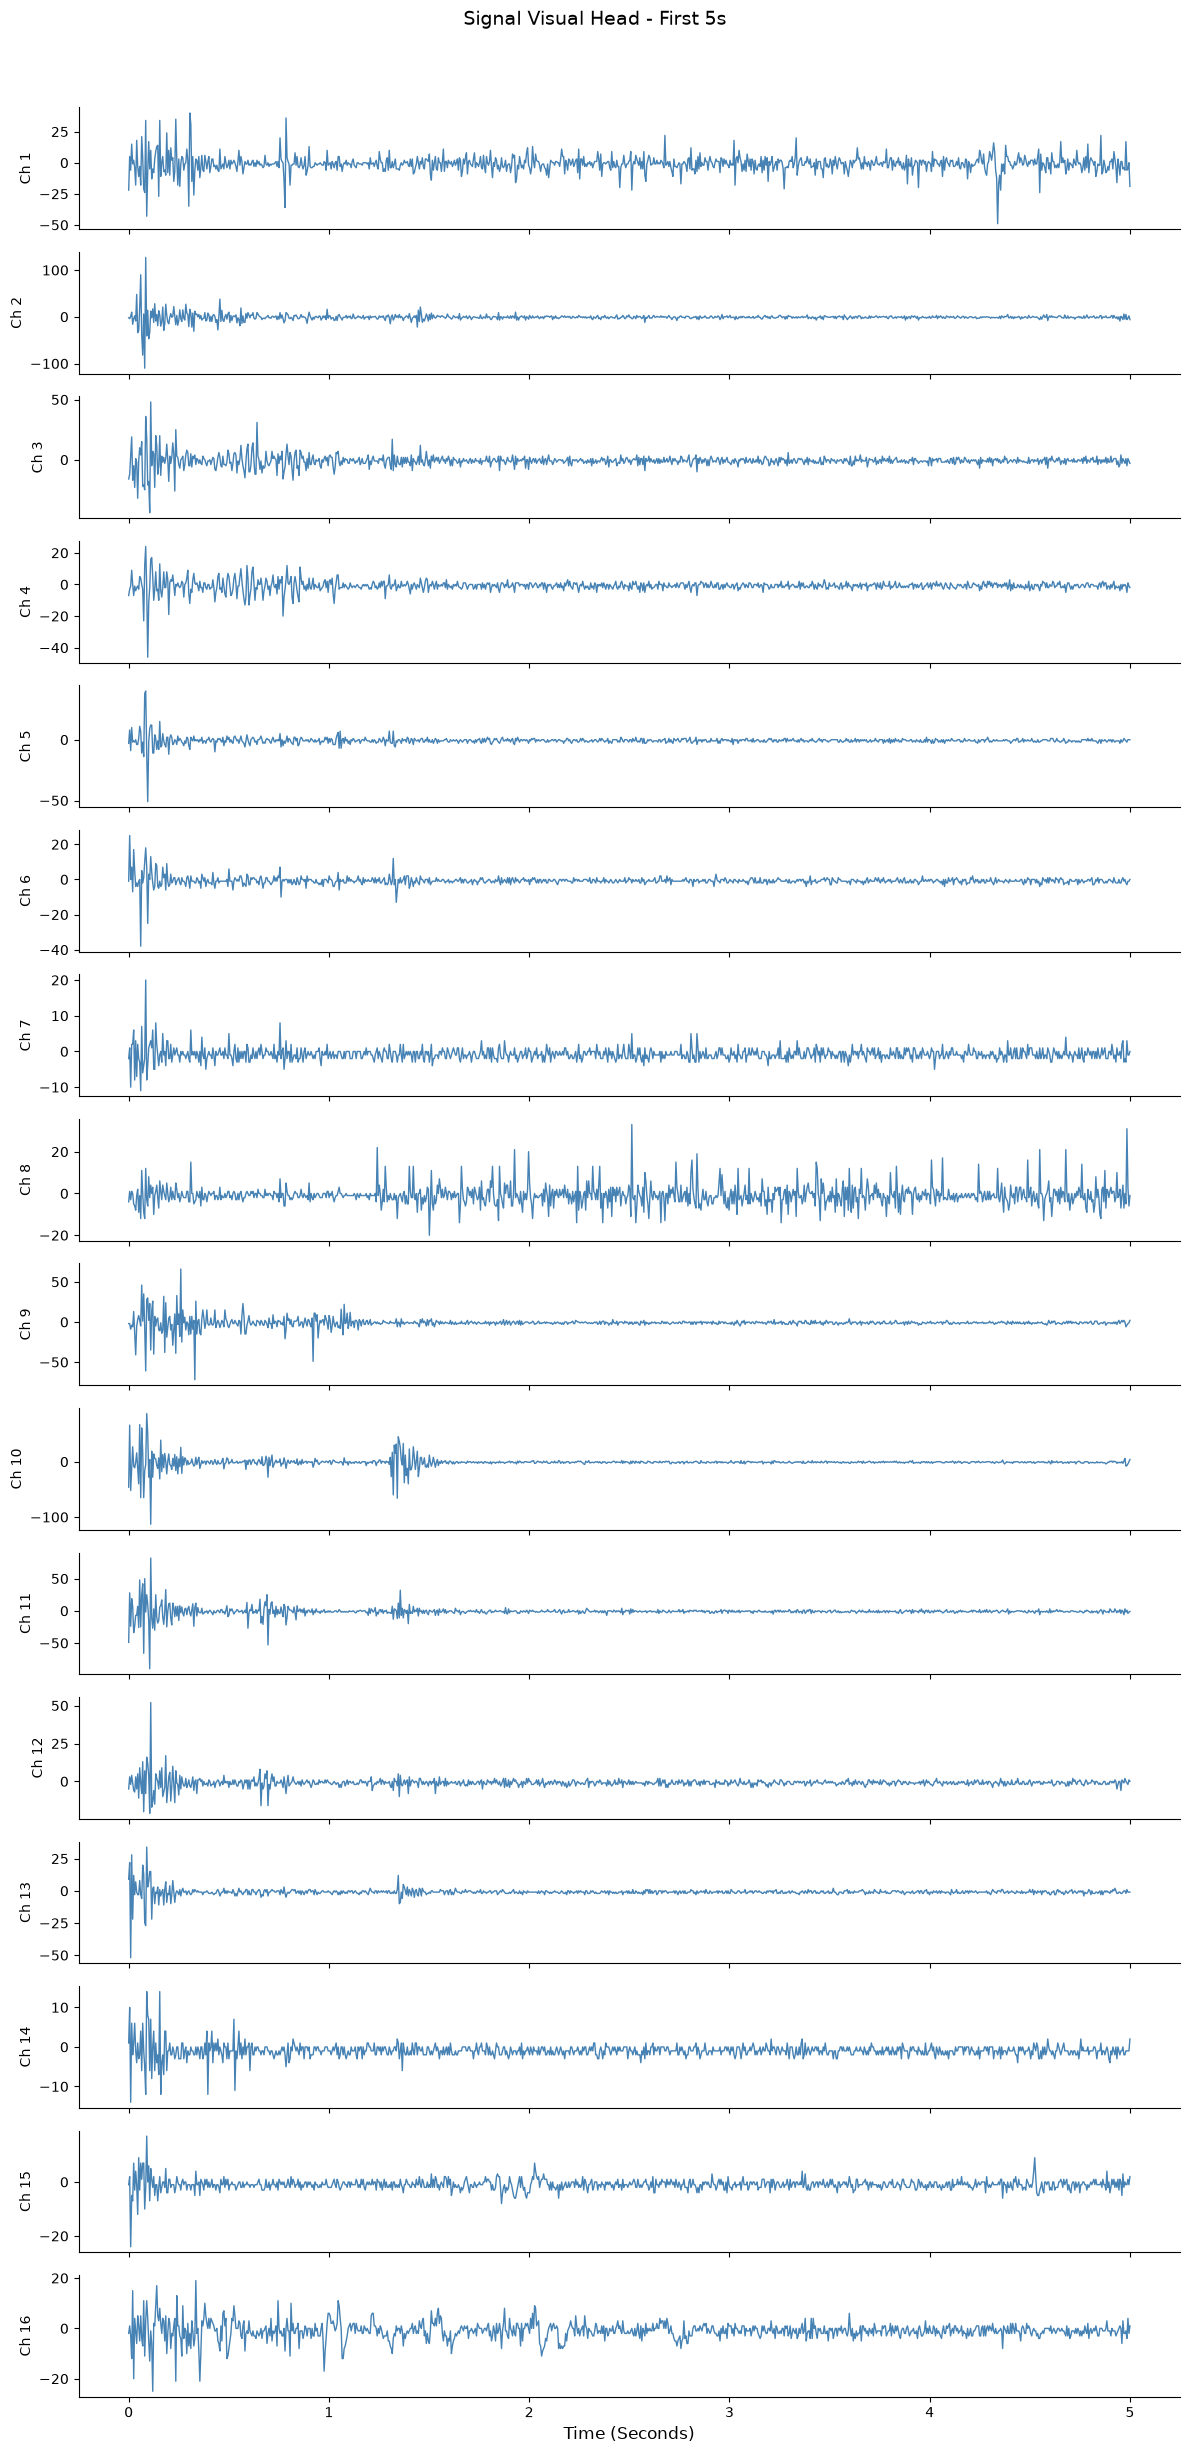

In [8]:
print("SINAL BRUTO:")
signal_head(df, labels=restim, n_seconds=5, sampling_rate=fs, n_channels_to_show=16)

## 4. Preprocessing: Filtering and Rectification

SINAL FILTRADO E RETIFICADO:
=== Signal Structural Head ===
Total Shape : (568540, 16) (Samples x Channels)
Previewing  : First 5s (1000 samples) across 4 channels.
----------------------------------------
           0          1          2          3
0   0.056616   0.058012   0.027617   0.035883
1  20.220911   1.310739   0.069877   2.027053
2   2.354961   4.410159  15.951767   3.162639
3  18.971299  20.256646  24.031185  10.697405
4   1.395125  27.261652   7.170712   2.067265


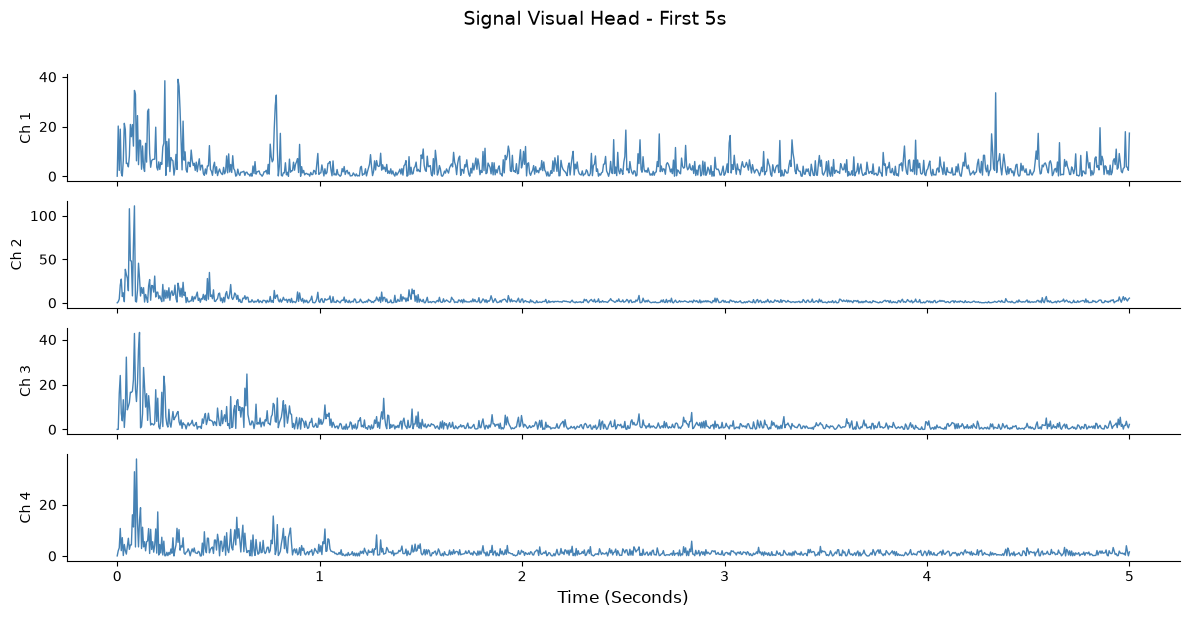

In [9]:
# 4.1. Filtro Passa-Banda (15Hz a 90Hz para respeitar o Nyquist de 100Hz da DB5)
# Passamos df.values para garantir que a função do SciPy receba um array NumPy puro
df_filtered = apply_bandpass_filter(df.values, lowcut=15.0, highcut=90.0, fs=fs, order=4)

# 4.2. Retificação de Onda Completa (Transforma tudo em energia positiva)
df_rectified = rectify_signal(df_filtered)

# 4.3. Visualização do Sinal Limpo (Vamos olhar os mesmos 4 canais)
print("SINAL FILTRADO E RETIFICADO:")
signal_head(df_rectified, labels=restim, n_seconds=5, sampling_rate=fs, n_channels_to_show=4)

ENVELOPE LINEAR DO SINAL:
=== Signal Structural Head ===
Total Shape : (568540, 16) (Samples x Channels)
Previewing  : First 5s (1000 samples) across 4 channels.
----------------------------------------
          0          1         2         3
0  0.808530   0.837810  0.554980  0.658894
1  2.199398   4.045083  2.167557  1.463377
2  3.563866   7.268013  3.778508  2.258464
3  4.891687  10.464094  5.373354  3.041109
4  6.172846  13.591117  6.937535  3.808005


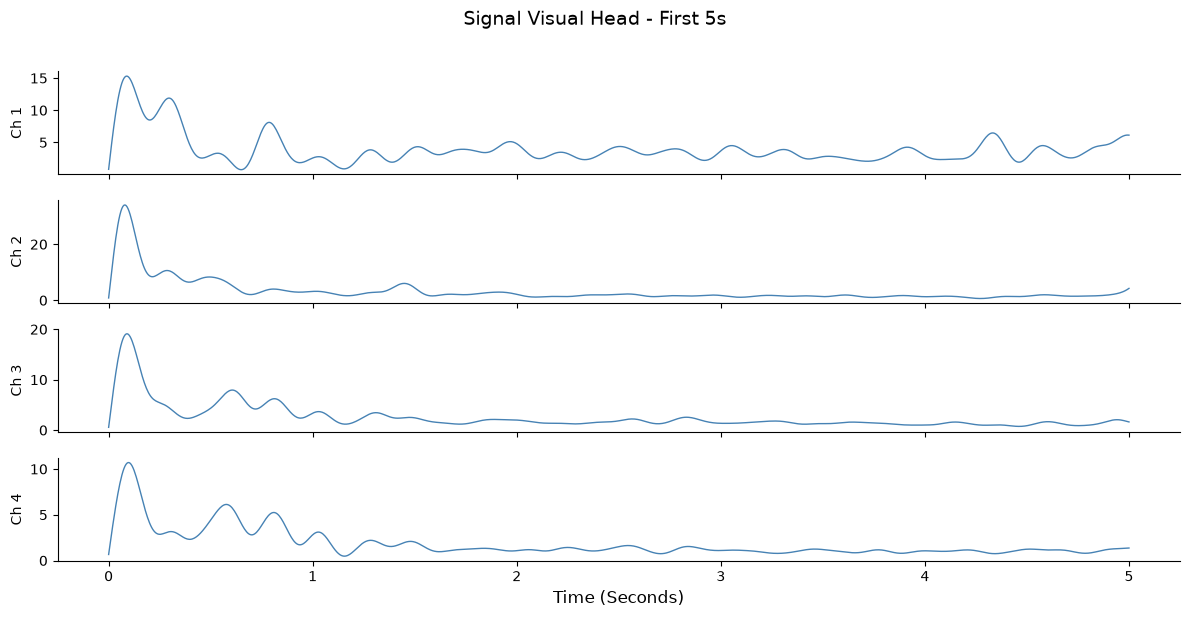

In [10]:
# 4.4. Envelopamento (Filtro Passa-Baixa em 5 Hz)
# É fundamental que o envelope seja aplicado SOBRE o sinal retificado
df_envelope = apply_lowpass_filter(df_rectified, cutoff=5.0, fs=fs, order=4)

# 4.5. Visualização do Envelope
print("ENVELOPE LINEAR DO SINAL:")
signal_head(df_envelope, labels=restim, n_seconds=5, sampling_rate=fs, n_channels_to_show=4)

SOBREPOSIÇÃO: SINAL RETIFICADO (Azul) vs ENVELOPE (Vermelho)


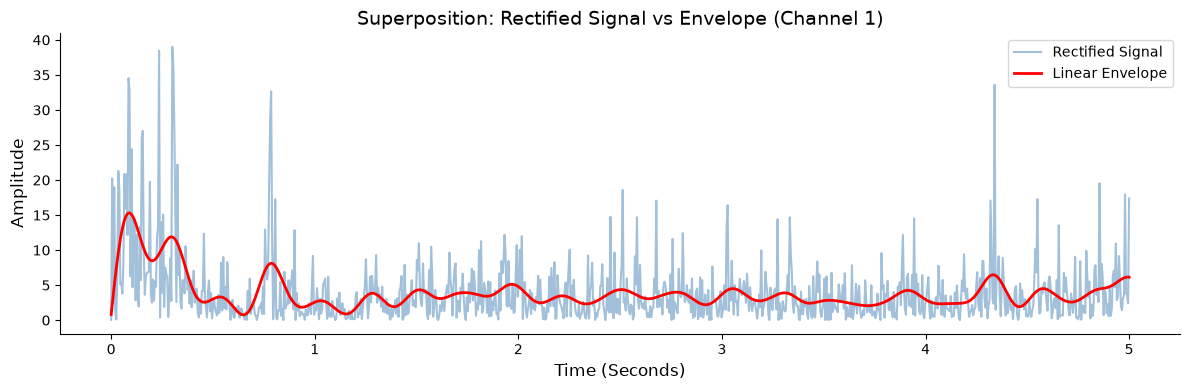

In [11]:
# 4.6. Visualização Sobreposta (Sinal Retificado vs Envelope)
print("SOBREPOSIÇÃO: SINAL RETIFICADO (Azul) vs ENVELOPE (Vermelho)")

# Vamos analisar o Canal 1 (índice 0) nos primeiros 5 segundos
plot_signal_and_envelope(df_rectified, df_envelope, channel_idx=0, n_seconds=5, sampling_rate=fs)

In [12]:
# 4.7. Cálculo do RMS Contínuo (Usando janela padrão de 200ms)
# É calculado sobre o sinal filtrado (antes de aplicar o passa-baixa)
df_rms = calculate_rms(df_filtered, window_ms=200, fs=fs)

SOBREPOSIÇÃO: SINAL RETIFICADO (Azul) vs RMS (Verde)


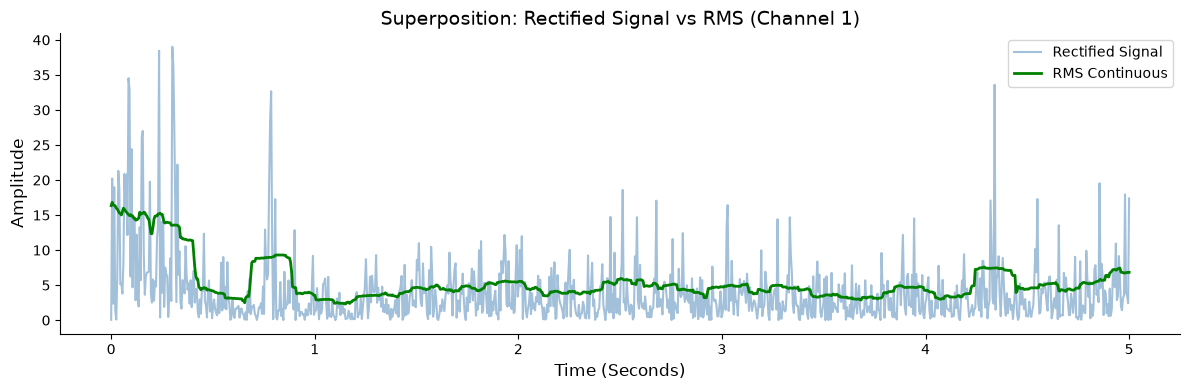

In [13]:
# 4.8. Visualização Sobreposta (Sinal Retificado vs RMS)
print("SOBREPOSIÇÃO: SINAL RETIFICADO (Azul) vs RMS (Verde)")

# Vamos analisar o mesmo Canal 1 (índice 0) nos mesmos primeiros 5 segundos
plot_signal_and_rms(df_rectified, df_rms, channel_idx=0, n_seconds=5, sampling_rate=fs)